In [72]:
import mesa
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import itertools
from io import StringIO

In [73]:
try:
    demographic_distributions = pd.read_csv('demog_distrib.csv')
except:
    raise FileNotFoundError("The demographic distribution file 'demog_distrib.csv' was not found. Please ensure it is in the correct directory.")
    multiline_csv = """
        region,gender_m,gender_f,age_<19,age_20_29,age_30_39,age_40_49,age_50_59,age_60_69,age_>70,no_education,early_childhood,elementary,high_school,post_secondary,short-cycle_tertiary,college,post_baccalaureate,below_poverty_line,low_income,middle_income,high_income,urban,rural,total_pop
        NCR,0.4979455817342733,0.5020544182657267,0.10886509803868027,0.2500000731402697,0.21171816343027475,0.15869809929893589,0.11471534440924068,0.06833544156097329,0.08766778012162545,0.0023356758927292757,0.00012493558331649456,0.08077632699916809,0.43901992268242684,0.013746631256549438,0.01929686873224766,0.43718006552613214,0.007519573327430041,0.007879037641248839,0.1975561139893578,0.7778949788770704,0.016669869492323006,1.0,0.0,0.1233451341820353
        CAR,0.5122105095077328,0.4877894904922671,0.12992193112976164,0.242831056749671,0.19080093093885211,0.14060994857102052,0.11141755405580678,0.07384408668748697,0.11057449186740097,0.01956568965396418,0.0003402660927563812,0.18125048178408443,0.3781711125766864,0.022009843578820656,0.02570916670624758,0.3630358898970559,0.0099175497103845,0.06910579765655024,0.39043535623719067,0.5333413170303536,0.007117529075905631,0.32239864934426005,0.6776013506557399,0.016482651506400152
        R1,0.5065430001377473,0.4934569998622526,0.12202015954775337,0.21498626635675935,0.17906441867074685,0.14846326274766306,0.1191982413928698,0.08061945446971201,0.13564819681449555,0.005668311194643809,0.000304617236421548,0.158934637542476,0.49635436839082314,0.015501133662238929,0.024812434512578075,0.29385471052379897,0.004569786937019528,0.09002209726972163,0.4118193552339355,0.48956706061805033,0.008591486878292635,0.24278882449592773,0.7572111755040722,0.048701950967783306
        R2,0.5094055353790531,0.49059446462094686,0.12316046136385732,0.22578753175179453,0.18399819950009064,0.1526646579602145,0.12033578468642064,0.08004532587588302,0.11400803886173934,0.012487267341336846,0.0005931404245632703,0.24312531915194288,0.4046069403922518,0.012806180576694432,0.021324410382898305,0.2994060575181981,0.005650684212114349,0.10573693533789608,0.471369186857916,0.4161482319481325,0.006745645856055394,0.21955029816187735,0.7804497018381227,0.03386259438383724
        R3,0.5063281155968556,0.49367188440314436,0.1232473227561026,0.23557628968814107,0.18948151978825006,0.1543669145865521,0.11804329358744693,0.07327388560097046,0.10601077399253674,0.0058473168992824376,0.0003866259967916463,0.17592572102824627,0.4800070675048761,0.012459745090554987,0.02836025516857157,0.2939576387700111,0.0030556295416658877,0.032107662133616384,0.33072789724684176,0.6330420915323657,0.004122349087176123,0.6755929049657982,0.3244070950342019,0.11399786593990599
        CALABARZON,0.5027331244497288,0.49726687555027116,0.11114056959760212,0.2213749316394275,0.20543589966898138,0.16919651814297532,0.12299255786400219,0.08453509594369493,0.08532442714331658,0.004872245416521201,0.00023125810441622542,0.13801684765564173,0.4797254839523925,0.01091249726665161,0.025359527663409206,0.3370949278234276,0.00378721211753997,0.046902417816506746,0.31023967348674913,0.6302123439009523,0.012645564795791866,0.6943289381154611,0.30567106188453896,0.14852497642730556
        MIMAROPA,0.51017359283277,0.4898264071672301,0.14638108456094628,0.23568265457629567,0.18024750199274006,0.14593820537916558,0.11117305460778161,0.07210107679326062,0.10847642208981019,0.03051349955862023,0.0005797157773373234,0.2646923018556457,0.4300269639549108,0.010586174542103189,0.020420522956374653,0.23969188545963643,0.003488935895371712,0.20570233403603244,0.4890585714236833,0.29771963602880713,0.007519458511477085,0.3306238294211009,0.669376170578899,0.02956082093813853
        R5,0.5073553431597962,0.49264465684020375,0.15514038204010264,0.22555568060781925,0.1699485895386247,0.14154758933799738,0.11395072956345031,0.07521660644351595,0.11864042246848974,0.007505001076228594,0.0004232162326379743,0.2629793419301169,0.45112191186365164,0.017062111685935924,0.018470741885261488,0.23794962648094323,0.004488048845224279,0.17321855003434222,0.5091674807903452,0.31267545456022305,0.004938514615089359,0.2582708578808103,0.7417291421191897,0.055833763692272366
        R6,0.5076864006184041,0.49231359938159586,0.12213057449970258,0.2188264823444452,0.17860843015152147,0.14295517352643558,0.11694321950748389,0.08212187128906293,0.13841424868134836,0.010436084968807493,0.00040969103230655154,0.21690170214690305,0.42345722524141804,0.015873329203523308,0.03850377891973645,0.29037834419502084,0.004039844292284314,0.12803623163646435,0.4358203242840371,0.4270088448395545,0.00913459923994402,0.21144594579790293,0.7885540542020971,0.04342847536580157
        NIR,0.5082974960359194,0.49170250396408055,0.13094469550247473,0.2243010711745189,0.17712571920769893,0.14323375050697185,0.1193170836960742,0.08193039875245986,0.12314728115980156,0.011015955373991604,0.0003737142801754985,0.23284966472515936,0.4246473004169194,0.00989068408560534,0.02468093829208984,0.29284785897796506,0.0036938838480939404,0.24358753104417596,0.47548455836475007,0.27583081786826386,0.005097092722810101,0.33301873284458366,0.6669812671554163,0.04274373233842389
        R7,0.5068583112323745,0.49314168876762554,0.13004801380778602,0.24042033961780276,0.18929082445752946,0.14600451439701861,0.10997665458349701,0.07220775995945591,0.11205189317691022,0.011595942120474202,0.0003375401973568807,0.24880554758086915,0.42583819938822637,0.00390505281516604,0.01085119917439104,0.2953187663193055,0.00334775240421085,0.11690171801648853,0.40573942716715955,0.47140033233510575,0.0059585224812461314,0.5762886172853698,0.42371138271463016,0.06089920933985477
        R8,0.5122731662191339,0.48772683378086606,0.1446795794455623,0.22421354951651257,0.166188094140928,0.14123803543455132,0.11585592928349155,0.07867017794783822,0.129154634231116,0.01799582900901314,0.000400402039005641,0.29970010771240463,0.40876792069224044,0.0036648409032127107,0.010169491525423728,0.25366893331980106,0.005632474798898649,0.21966221551148132,0.4803362435729889,0.2950928226291966,0.004908718286333194,0.1476029511371409,0.8523970488628592,0.04170088625674667
        R9,0.5090372051070422,0.4909627948929578,0.14503113771578693,0.24297151136837639,0.18020468200013173,0.14536337092300824,0.11155827619263671,0.07194605235234283,0.10292496944771717,0.029185505608632378,0.0002955919316288443,0.2857272830571937,0.393302441308211,0.0034897028969180736,0.011189150331340204,0.273251116865023,0.003559208001052729,0.2542960712782039,0.47801243683732725,0.26182176824673514,0.005869723637733729,0.34397705300803794,0.6560229469919621,0.03554516524389092
        R10,0.5101931028368157,0.4898068971631843,0.14073799697607595,0.2439310900280151,0.188339526461582,0.1459635893484185,0.11161054284603823,0.07113298301345489,0.0982842713264153,0.014341013703721631,0.0003316428511246278,0.24178048589561796,0.4436141422072595,0.010318574330126257,0.010118991064764769,0.27564630021027947,0.0038488497371058157,0.18319364000128738,0.46446158851128544,0.3451518932184898,0.007192878268937313,0.49601921866813276,0.5039807813318673,0.046083871077636666
        R11,0.5128402646195243,0.48715973538047574,0.13058041979688534,0.24011852989768717,0.1962241155246779,0.15062903426359786,0.11132167236703555,0.07257778918026439,0.09854843896985178,0.01730847666675333,0.00041597372656269,0.2319447694239183,0.4469455982962969,0.018769696202199013,0.01396251595893825,0.2671661146907775,0.003486855034554054,0.16277831605038648,0.4516469936679358,0.3795809467604981,0.005993743521179788,0.6524961526575077,0.3475038473424923,0.04807163106481144
        R12,0.5113835211533322,0.48861647884666776,0.1435630684131719,0.24943475777842244,0.1952118324905652,0.1514985748610961,0.10744903388461254,0.06403921180907432,0.08880352076305749,0.0369208099580148,0.0004052200048543773,0.23965888531791868,0.4387000597329404,0.008714467937870856,0.023828106844499836,0.24803595682014187,0.0037364933837591816,0.26329501636485886,0.43857768824426535,0.29249304502056406,0.005634250370311678,0.5691981966801013,0.43080180331989865,0.04004685210768089
        CARAGA,0.5131365057560082,0.4868634942439918,0.1434141510962909,0.23334177542676765,0.18028049227151954,0.14179991049068058,0.1158962306465834,0.07457474399888585,0.11069269606927208,0.012695845257123169,0.0003807105249445152,0.25786970129111914,0.4455376579071343,0.00471953438464737,0.017164408457728902,0.257931380649909,0.003700761527393611,0.22445937136026733,0.6080233410784973,0.1672426834518992,0.0002746041093362262,0.27204281936635477,0.7279571806336452,0.025723898643308072
        BARMM,0.5011411269608279,0.4988588730391721,0.18397657969940906,0.30246602935857875,0.20396207285495638,0.14755346295554478,0.07691412176221256,0.037708737186571306,0.04741899618272719,0.1423020665604911,0.0006437259546582335,0.31126976963882164,0.3435315725982753,0.0006851660324812949,0.0014518074722079308,0.19893414715090685,0.0011817445921576408,0.24733151767736583,0.43506126510414617,0.31042006462874194,0.0071871525897459505,0.6315478053167597,0.36845219468324025,0.04544652052416665
    """
    
    # Turn the multiline string csv into a pandas DataFrame
    demographic_distributions = pd.read_csv(StringIO(multiline_csv))

# Split the demographic distributions into separate DataFrames for each category
region_cols = demographic_distributions[['region', 'total_pop']]
gender_cols = demographic_distributions[['gender_m', 'gender_f']]
age_cols = demographic_distributions[['age_<19', 'age_20_29', 'age_30_39', 'age_40_49', 'age_50_59', 'age_60_69', 'age_>70']]
educ_cols = demographic_distributions[['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']]
income_cols = demographic_distributions[['below_poverty_line', 'low_income', 'middle_income', 'high_income']]
split_cols = demographic_distributions[['urban', 'rural']]

# Define the issues and their corresponding labels
issues = {
    'gov': 'Governance', 'edu': 'Education', 'labor': 'Labor', 'sec': 'Security',
    'energy': 'Energy', 'env': 'Environment', 'health': 'Health', 'econ': 'Economy',
    'agri': 'Food & Agriculture', 'crime': 'Anti-Drugs & Crime'
}

# Define Turnout Probabilities for each region
turnout_prob = [
    0.8143, #NCR
    0.8546, #CAR
    0.8754, #R1
    0.8438, #R2
    0.8648, #R3
    0.8306, #CALABARZON
    0.8389, #MIMAROPA
    0.8610, #R5
    0.8519, #R6
    0.8657, #NIR
    0.8675, #R7
    0.8548, #R8
    0.8167, #R9
    0.8561, #R10
    0.8124, #R11
    0.8066, #R12
    0.8533, #CARAGA
    0.7754, #BARMM
]

# Constants for the model
very_likely_modifier = 1.25
likely_modifier = 1.1
slightly_likely_modifier = 1.05
neutral_modifier = 1.0
slightly_unlikely_modifier = 0.95
unlikely_modifier = 0.9
very_unlikely_modifier = 0.75

# Voter Class

In [74]:
class VoterAgent(mesa.Agent):
    """A Voter agent with demographic attributes and voting behavior."""

    def __init__(self, id, model):
        """Initialize a voter agent with demographic attributes and voting behavior."""
        super().__init__(id, model)
        self.approval_threshold = np.random.uniform(0.4, 0.7)       # Approval threshold for voting
        self.ranked_vote = []                                       # Store Candidate by Rankings
        self.approval_scores = {}                                   # Store Approval Scores for Candidates
        self.will_vote = False                                      # Flag for voting

        # Initialize demographic attributes ----
        self._initialize_demographics()
        
        # Initialize Turnout Probability ----
        self._initialize_turnout_probability()

        # Developing Issue Stances and Priorities ----
        self.issue_stances = {}
        self.issue_priorities = {}
        self._initialize_issue_stances_and_priorities()

        # Develop Susceptibility Factors ---
        self._initialize_popularity_influence()
        self._initialize_dynasty_preference()
        self._initialize_vote_buying_susceptibility()

    def _initialize_demographics(self):
        """Set demographic attributes based on distributions."""
        try:
            # Region ---
            region_probs = region_cols['total_pop']
            self.region_idx = np.random.choice(range(18), p=region_probs)
            self.region = region_cols['region'][self.region_idx]
            
            # Gender ---
            self.gender = np.random.choice(['m', 'f'], p=list(gender_cols.iloc[self.region_idx, :].astype(float).values))   
            self.age_group = np.random.choice(
                ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70'],
                p=list(age_cols.iloc[self.region_idx, :].astype(float).values)
            )  

            # Education Attainment ---
            self.educ_attainment = np.random.choice(
                ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate'],
                p=list(educ_cols.iloc[self.region_idx, :].astype(float).values)
            )

            # Income Group ---
            self.income_group = np.random.choice(
                ['below_poverty_line', 'low_income', 'middle_income', 'high_income'],
                p=list(income_cols.iloc[self.region_idx, :].astype(float).values)
            )

            # Urban/Rural Split ---
            self.split = np.random.choice(
                ['urban', 'rural'], 
                p=list(split_cols.iloc[self.region_idx, :].astype(float).values)
            )
        except:
            self.region = 'Unknown'
            self.gender = 'Unknown'
            self.age_group = 'Unknown'
            self.educ_attainment = 'Unknown'
            self.income_group = 'Unknown'
            self.split = 'Unknown'
    
    def _initialize_issue_stances_and_priorities(self):
        """Initialize issue stances and priorities based on demographic attributes."""
        self.issues = list(issues.keys())

        # Stance Definitions:
        # 0=StrictGov, PrivateEdu, LessLaborRights, TightSecurity, TradEnergy, LessEnvCare, PrivateHealth, ConservativeEcon, ConservativeAgri, PunitiveCrime
        # 1=GoodGov, Free/PublicEdu, MoreLaborRights, LessSecurity/Open, RenewableEnergy, MoreEnvCare, PublicHealth, LiberalEcon, LiberalAgri, RehabCrime
        
        # 0 = Leaning Towards Conservative (Status Quo)
        # 1 = Leaning Towards Liberal (Reform)

        # Initialize base priorities (equal initially) & stance beta parameters (neutral Beta(2,2))
        base_priorities = {issue: 1.0 for issue in self.issues}
        stance_a = {issue: 2.0 for issue in self.issues} # Parameter 'a' for beta(a,b)
        stance_b = {issue: 2.0 for issue in self.issues} # Parameter 'b' for beta(a,b)

        stance_bias_strength = 0.5 # Strength of bias towards a or b

        # Add noise for issue priorities
        for issue in self.issues:
            base_priorities[issue] += np.random.normal(0, 0.05)

        # Age Group Effects ---
        if self.age_group in ['<19', '20-29']: # Youth
            # Priorities
            base_priorities['gov'] *= likely_modifier               # Gov: Less trust -> higher priority
            base_priorities['edu'] *= likely_modifier               # Edu: Quality concern -> higher priority
            base_priorities['econ'] *= likely_modifier              # Econ: Job concern -> higher priority
            base_priorities['health'] *= likely_modifier            # Health: Access concern -> higher priority
            base_priorities['energy'] *= likely_modifier            # Energy: Advocate renewables -> higher priority
            base_priorities['crime'] *= slightly_likely_modifier    # Crime: Favor rehab -> moderate priority
           
           # Stances (Bias towards 1: reform gov, public edu, renewables, rehab crime)
            stance_a['gov'] += stance_bias_strength; stance_b['gov'] -= stance_bias_strength * 0.5
            stance_a['edu'] += stance_bias_strength * 0.5; stance_b['edu'] -= stance_bias_strength * 0.25
            stance_a['health'] += stance_bias_strength * 0.25; stance_b['health'] -= stance_bias_strength * 0.1
            stance_a['energy'] += stance_bias_strength; stance_b['energy'] -= stance_bias_strength * 0.5
            stance_a['crime'] += stance_bias_strength; stance_b['crime'] -= stance_bias_strength * 0.5
        elif self.age_group in ['50-59', '60-69', '>70']: # Older
            # Priorities
            base_priorities['gov'] *= slightly_unlikely_modifier    # Gov: Higher trust -> lower priority?
            base_priorities['health'] *= likely_modifier            # Health: Senior needs -> higher priority
            base_priorities['sec'] *= slightly_likely_modifier      # Security: Safety -> higher priority
            base_priorities['crime'] *= slightly_likely_modifier    # Crime: Enforcement -> higher priority
            base_priorities['econ'] *= slightly_likely_modifier     # Economy: Inflation/fixed income -> higher priority

            # Stances (Bias towards 0: status quo gov, tight sec, punitive crime, conservative econ; Bias towards 1: public health)
            stance_a['gov'] -= stance_bias_strength * 0.5; stance_b['gov'] += stance_bias_strength
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength * 0.5
            stance_a['sec'] -= stance_bias_strength; stance_b['sec'] += stance_bias_strength*0.5
            stance_a['crime'] -= stance_bias_strength; stance_b['crime'] += stance_bias_strength * 0.5
            stance_a['econ'] -= stance_bias_strength*0.5; stance_b['econ'] += stance_bias_strength*0.25

        # Income Effects ---
        if self.income_group in ['below_poverty_line', 'low_income']: # Poor/Low Income
             base_priorities['econ'] *= likely_modifier             # Priorities based on direct needs
             base_priorities['labor'] *= likely_modifier
             base_priorities['agri'] *= likely_modifier
             base_priorities['health'] *= likely_modifier
             base_priorities['env'] *= slightly_likely_modifier     # Immediate impacts
             base_priorities['sec'] *= slightly_likely_modifier     # Higher fear
             base_priorities['crime'] *= slightly_likely_modifier   # Disproportionately affected

             # Stances (Bias towards 1: liberal econ, more labor rights, agri support, public health)
             stance_a['econ'] += stance_bias_strength; stance_b['econ'] -= stance_bias_strength*0.5
             stance_a['labor'] += stance_bias_strength; stance_b['labor'] -= stance_bias_strength*0.5
             stance_a['agri'] += stance_bias_strength; stance_b['agri'] -= stance_bias_strength*0.5
             stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength*0.5
        elif self.income_group == 'middle_income': # Middle Income
             base_priorities['econ'] *= likely_modifier             # Priorities based on stability/mobility
             base_priorities['labor'] *= likely_modifier
             base_priorities['gov'] *= slightly_likely_modifier     # Supported populists -> slight priority increase

             # Stances (Bias towards 0: populist gov support)
             stance_a['gov'] -= stance_bias_strength*0.5; stance_b['gov'] += stance_bias_strength*0.25

        elif self.income_group == 'high_income': # High Income
             base_priorities['econ'] *= likely_modifier             # Priorities based on growth/investment
             base_priorities['env'] *= likely_modifier              # Broader sustainability focus

             # Stances (Bias towards 0: conservative econ, status quo gov; Bias towards 1: env care)
             stance_a['econ'] -= stance_bias_strength; stance_b['econ'] += stance_bias_strength*0.5
             stance_a['gov'] -= stance_bias_strength*0.25; stance_b['gov'] += stance_bias_strength*0.1
             stance_a['env'] += stance_bias_strength; stance_b['env'] -= stance_bias_strength * 0.5

        # Urban/Rural Effects ---
        if self.split == 'urban':
            base_priorities['sec'] *= likely_modifier               # Higher crime concerns
            base_priorities['labor'] *= likely_modifier             # Focus min wage/security
            base_priorities['env'] *= likely_modifier               # Focus pollution/dev
            base_priorities['econ'] *= likely_modifier              # Focus industry/service jobs
            base_priorities['agri'] *= unlikely_modifier            # Less direct focus
            if self.region == 'NCR': 
                base_priorities['gov'] *= slightly_likely_modifier  # Less trust in NCR
            # Stances (Bias towards 0: tight sec; Bias towards 1: labor rights, env care, NCR gov reform)
            stance_a['sec'] -= stance_bias_strength*0.5; stance_b['sec'] += stance_bias_strength*0.25
            stance_a['labor'] += stance_bias_strength*0.25; stance_b['labor'] -= stance_bias_strength*0.1
            stance_a['env'] += stance_bias_strength*0.5; stance_b['env'] -= stance_bias_strength*0.25
            if self.region == 'NCR': stance_a['gov'] += stance_bias_strength; stance_b['gov'] -= stance_bias_strength * 0.5
        elif self.split == 'rural':
            base_priorities['labor'] *= likely_modifier             # Focus agri/off-farm
            base_priorities['energy'] *= likely_modifier            # Prioritize access
            base_priorities['env'] *= likely_modifier               # Focus resources/agri
            base_priorities['health'] *= likely_modifier            # Prioritize infrastructure
            base_priorities['econ'] *= likely_modifier              # Focus agri/infrastructure
            base_priorities['agri'] *= likely_modifier              # Focus subsidies/prices/land reform

            # Stances (Bias towards 1: energy access, public health, liberal agri; Bias towards 0: less env care)
            stance_a['energy'] += stance_bias_strength*0.5; stance_b['energy'] -= stance_bias_strength*0.25
            stance_a['env'] -= stance_bias_strength*0.5; stance_b['env'] += stance_bias_strength*0.25
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength*0.5
            stance_a['agri'] += stance_bias_strength; stance_b['agri'] -= stance_bias_strength*0.5

        # Gender Effects ---
        if self.gender == 'f':
            base_priorities['env'] *= slightly_likely_modifier      # Stronger concerns
            base_priorities['sec'] *= slightly_likely_modifier      # Higher fear
            base_priorities['health'] *= slightly_likely_modifier   # Possibly higher health priority

            # Stances (Bias towards 1: env care)
            stance_a['env'] += stance_bias_strength; stance_b['env'] -= stance_bias_strength * 0.5

        # Education Effects ---
        if self.educ_attainment in ['college', 'post_baccalaureate']: # High Education
            base_priorities['edu'] *= slightly_likely_modifier      # Value quality
            base_priorities['energy'] *= slightly_likely_modifier   # Awareness/support renewables
            base_priorities['health'] *= slightly_likely_modifier   # Favor prevention
            base_priorities['env'] *= slightly_likely_modifier      # Higher awareness

            # Stances (Bias towards 1: public/quality edu, renewables, public health, env care)
            stance_a['edu'] += stance_bias_strength; stance_b['edu'] -= stance_bias_strength*0.5
            stance_a['energy'] += stance_bias_strength; stance_b['energy'] -= stance_bias_strength * 0.5
            stance_a['health'] += stance_bias_strength*0.5; stance_b['health'] -= stance_bias_strength*0.25
            stance_a['env'] += stance_bias_strength*0.5; stance_b['env'] -= stance_bias_strength*0.25
        elif self.educ_attainment in ['no_education', 'early_childhood', 'elementary']: # Low Education
            base_priorities['sec'] *= slightly_likely_modifier      # Higher fear of crime
            base_priorities['energy'] *= unlikely_modifier          # Less awareness -> less priority
            base_priorities['env'] *= unlikely_modifier             # Less awareness -> less priority
            # Stances: neutral

        # --- Final Stance Generation and Priority Normalization ---
        final_stances = {}
        for issue in self.issues:
            a = max(0.1, stance_a[issue]); b = max(0.1, stance_b[issue])
            final_stances[issue] = np.random.beta(a, b)
        self.issue_stances = final_stances

        total_priority = sum(base_priorities.values())
        if total_priority > 0:
            self.issue_priorities = {k: max(0.0, v) / total_priority for k, v in base_priorities.items()}
        else:
            self.issue_priorities = {issue: 1.0 / len(self.issues) for issue in self.issues}


    def _initialize_popularity_influence(self):
        """Initialize the popularity influence factors for the voter agent."""
        base_influence = np.random.uniform(0.05, 0.2)

        # Age Effect ---
        if self.age_group in ['<19', '20-29']: base_influence *= likely_modifier                # More susceptible to trends
        elif self.age_group in ['50-59', '60-69', '>70']: base_influence *= unlikely_modifier   # Less susceptible

        ## Education Adjustments
        if self.educ_attainment in ['no_education', 'early_childhood', 'elementary']: base_influence *= likely_modifier # More susceptible
        elif self.educ_attainment in ['college', 'post_baccalaureate']: base_influence *= unlikely_modifier             # Less susceptible

        final_influence = base_influence * np.random.uniform(0.8, 1.2) # Small individual noise
        
        # Clamp the influence factor to a reasonable range
        self.popularity_influence = max(0.0, min(1.0, final_influence))

    def _initialize_dynasty_preference(self):
        """Initialize the dynasty preference for the voter agent."""
        base_pref = 0.0
        pref_shift_strength = 0.25 # Base magnitude of shift per factor (reduced slightly)

        # Education effect: Higher education -> more critical/anti-dynasty
        if self.educ_attainment in ['college', 'post_baccalaureate']:
            base_pref -= pref_shift_strength * likely_modifier                              # Strong anti shift
        # Lower education -> potentially more accepting
        elif self.educ_attainment in ['no_education', 'early_childhood', 'elementary']:
            base_pref += pref_shift_strength * slightly_likely_modifier                     # Slight pro shift

        # Age effect: Youth potentially more anti-dynasty
        if self.age_group in ['<19', '20-29']:
            base_pref -= pref_shift_strength * likely_modifier                              # Strong anti shift
        # Older individuals may be more accepting
        elif self.age_group in ['50-59', '60-69', '>70']:
            base_pref += pref_shift_strength * slightly_likely_modifier                     # Slight pro shift

        # Income effect: Lower income might favor dynasties due to patronage link
        if self.income_group in ['below_poverty_line', 'low_income']:
            base_pref += pref_shift_strength * slightly_likely_modifier                     # Moderate pro shift
        # Higher income might be more critical (speculative)
        elif self.income_group in ['high_income']:
            base_pref -= pref_shift_strength * slightly_likely_modifier                     # Slight anti shift

        # Add noise:
        base_pref += np.random.normal(0, 0.25) # Add some noise to the preference

        # Clamp the dynasty preference to a reasonable range
        self.dynasty_preference = max(-1.0, min(1.0, base_pref))

    def _initialize_turnout_probability(self):
        self.turnout_probability = 0.0
        if self.region_idx != -1 and self.region_idx < len(turnout_prob):
            base_rate = turnout_prob[self.region_idx]
            turnout_modifier = 1.0

            # Demographic adjustments to turnout probability (VT)

            # Gender
            if self.gender == 'f': turnout_modifier *= 1.05 # Women turnout slightly more
            elif self.gender == 'm' : turnout_modifier *= 0.95 # Men turnout slightly less

            # Age
            if self.age_group in ['<19', '20-29']: turnout_modifier *= 1.02 # Younger voters turnout more
            elif self.age_group in ['50-59', '60-69', '>70']: turnout_modifier *= 0.95 # Older voters turnout less

            # Calculate final probability and clamp between 0 and 1
            self.turnout_probability = max(0.0, min(1.0, base_rate * turnout_modifier))
        else:
            self.turnout_probability = 0.83

    def _initialize_vote_buying_susceptibility(self):
        """NEW: Initialize susceptibility to vote buying based on demographics."""
        base_susceptibility = 0.1 # Base susceptibility level
        modifier = 1.0

        # Income Effect: Lower income -> higher susceptibility (UCR)
        if self.income_group == 'below_poverty_line': modifier *= 2.5 # Example: 2.5x more susceptible
        elif self.income_group == 'low_income': modifier *= 1.8 # Example: 1.8x more susceptible
        elif self.income_group == 'middle_income': modifier *= 1.2 # Example: 1.2x more susceptible
        elif self.income_group == 'high_income': modifier *= 0.5 # Example: Half as susceptible

        # Education Effect: Lower education -> higher susceptibility (UCR)
        if self.educ_attainment in ['no_education', 'early_childhood', 'elementary']: modifier *= 1.5
        elif self.educ_attainment in ['college', 'post_baccalaureate']: modifier *= 0.7

        # Add some individual random variation (UCR)
        final_susceptibility = base_susceptibility * modifier * np.random.uniform(0.9, 1.1)
        self.vote_buying_susceptibility = max(0.0, min(1.0, final_susceptibility)) # Clamp

    def evaluate_candidate(self, candidate):
        """Evaluate a candidate based on their issue stances and the voter's priorities."""

        # Calculate issue score
        issue_score = self.get_issue_score(candidate)

        # Popularity influence (-1 to 1)
        candidate_popularity = getattr(candidate, 'popularity', 0) # Default to 0 if not set
        perceived_popularity = max(-1.0, min(1.0, candidate_popularity + np.random.normal(0, 0.05))) # Add noise to perceived popularity

        # Popularity add or subtracts from the score, weighted by the voter's susceptibility
        popularity_effect = self.popularity_influence * perceived_popularity * self.model.popularity_influence_base


        # Dynasty preference effect
        dynasty_effect = 0.0
        dynasty_effect_strength = 0.15
        if getattr(candidate, 'is_dynasty', False):
            # If the candidate is a dynasty, apply the dynasty preference effect
            dynasty_effect = self.dynasty_preference * dynasty_effect_strength * self.model.dynasty_strength

        # Combine final scores
        final_score = issue_score + popularity_effect + dynasty_effect

        return max(0.0, min(1.0, final_score))

    def step(self):
        """Evaluate candidates, potentially accept vote buying offers, and rank candidates."""
        candidates = [c for c in self.model.schedule.agents if isinstance(c, CandidateAgent)]
        if not candidates:
            self.initial_approval_scores = {} # Ensure attributes exist even if no candidates
            self.approval_scores = {}
            self.ranked_vote = []
            return

        # 1. Initial Evaluation
        initial_scores = {} # MODIFIED: Store initial scores here
        for c in candidates:
            score = self.evaluate_candidate(c)
            initial_scores[c] = score
            # Don't store in self.approval_scores yet

        # Make a copy to potentially modify with vote buying boost
        final_scores = initial_scores.copy()

        # 2. Simulate Vote Buying Offers and Acceptance
        vote_buying_boost = 0.15 # Example boost value
        accepted_offer_from = None

        shuffled_candidates = list(candidates) # Create a list copy to shuffle
        np.random.shuffle(shuffled_candidates)

        for candidate in shuffled_candidates:
            # Check if candidate makes an offer
            if hasattr(candidate, 'vote_buying_propensity') and \
               np.random.uniform(0,1) < candidate.vote_buying_propensity:

                # Check if voter accepts
                if np.random.random() < self.vote_buying_susceptibility:
                    # Apply boost to the final_scores dict
                    current_score = final_scores[candidate]
                    boosted_score = current_score + vote_buying_boost * self.model.vote_buy_boost
                    final_scores[candidate] = max(0.0, min(1.0, boosted_score)) # Apply boost and clamp
                    candidate.engaged_in_vote_buying = True # Flag candidate as engaged in vote buying

        # 3. Store initial and final scores, then Rank
        self.initial_approval_scores = {c.unique_id: s for c, s in initial_scores.items()} # Store initial scores by ID
        self.approval_scores = {c.unique_id: s for c, s in final_scores.items()} # Store final scores by ID

        # Rank based on the final (potentially boosted) scores
        sorted_candidates = sorted(final_scores.items(), key=lambda item: item[1], reverse=True)
        self.ranked_vote = [candidate for candidate, score in sorted_candidates]



    ## Helper Functions for Demographic Analysis
    def get_issue_score(self, candidate):
        """Calculates the issue alignment score (0-1) for a candidate."""
        issue_score = 0.0
        if hasattr(candidate, 'issue_stances') and self.issue_stances and self.issue_priorities:
            for issue in self.issues:
                voter_stance = self.issue_stances.get(issue, 0.5)
                candidate_stance = candidate.issue_stances.get(issue, 0.5)
                priority = self.issue_priorities.get(issue, 0.0)
                alignment = 1.0 - abs(voter_stance - candidate_stance)
                issue_score += alignment * priority
        return issue_score

# Candidate Class

In [75]:
class CandidateAgent(mesa.Agent):
    """A Candidate Agent with a Political Position."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.vote_count = 0         # Tracks first-choice votes
        self.engaged_in_vote_buying = False # Flag for vote buying

        # Politician Types
        types = [
            'Populist', 'Liberal',
            'Conservative', 'Progressive'
        ]
        self.politician_type = np.random.choice(types)

        # Initialize issue stances dictionary
        self.issue_stances = {}
        self._initialize_issue_stances()

        # Popularity; randomly generated between -1 and 1
        a_pop = 4.0; b_pop = 1.5 
        beta_popularity = np.random.beta(a_pop, b_pop) # Generates value between 0 and 1
        self.popularity = 2 * beta_popularity - 1 # Scale to -1 to 1 range (mostly positive)

        # Add Political Dynasty Status
        # Approx. 60-80% of candidates are from political dynasties
        dynasty_probability = np.random.uniform(0.6, 0.8)
        self.is_dynasty = np.random.choice([True, False], p=[dynasty_probability, 1 - dynasty_probability])

        # Initialize vote buying propensity
        self.vote_buying_propensity = 0.0 # Likelihood of offering to buy votes (0-1)
        self._initialize_vote_buying_propensity()

    def _initialize_issue_stances(self):
        """Set initial issue stances based on the candidate's politician type."""
        issues = [
            'gov', 'edu', 'labor', 'sec', 'energy', 'env',
            'health', 'econ', 'agri', 'crime'
        ]
        stances = {} # Temporary dict to hold base scores

        # Stance Definitions (User Provided):
        # 0=StrictGov, PrivateEdu, LessLaborRights, TightSecurity, TradEnergy, LessEnvCare, PrivateHealth, ConservativeEcon, ConservativeAgri, PunitiveCrime
        # 1=GoodGov, Free/PublicEdu, MoreLaborRights, LessSecurity/Open, RenewableEnergy, MoreEnvCare, PublicHealth, LiberalEcon, LiberalAgri, RehabCrime

        if self.politician_type == 'Populist':
            # Leans Heavily towards 0
            stances = { issue: np.random.beta(2.5, 8) for issue in issues } # Randomly generated between 0 and 1)
        elif self.politician_type == 'Liberal':
            # Lean Lightly towards 1
            stances = { issue: np.random.beta(8, 5) for issue in issues } # Randomly generated between 0 and 1)
        elif self.politician_type == 'Conservative':
            stances = { issue: np.random.beta(5, 8) for issue in issues } # Randomly generated between 0 and 1)
        elif self.politician_type == 'Progressive':
            stances = { issue: np.random.beta(8, 2.5) for issue in issues } # Randomly generated between 0 and 1)


        # Apply random variation and clamp between 0 and 1
        for issue in issues:
            base_stance = stances.get(issue, 0.5) # Default to 0.5 if issue missing
            variation = np.random.uniform(-0.25, 0.25) # Add some noise
            self.issue_stances[issue] = max(0.0, min(1.0, base_stance + variation))        

    def _initialize_vote_buying_propensity(self):
        """Set likelihood of engaging in vote buying based on type."""
        # Example: Conservative and Populist types are more likely
        if self.politician_type in ['Conservative', 'Populist']:
            self.vote_buying_propensity = np.random.uniform(0.4, 0.8) # Higher chance
        else:
            self.vote_buying_propensity = np.random.uniform(0.0, 0.2) # Lower chance
        self.vote_buying_propensity = max(0.0, min(1.0, self.vote_buying_propensity)) # Clamp

    def step(self):
        # No action yet for this version
        pass

# Election Class

In [76]:
class ElectionModel(mesa.Model):
    """Election Model. Runs Both Plurality Voting and IRV for Comparison."""
    def __init__(self, num_voters, num_candidates, vote_buy_boost=1, dynasty_strength=1, popularity_influence_base=1, verbose=False):
        super().__init__()
        self.num_voters = num_voters
        self.num_candidates = num_candidates
        self.plurality_winner = None    # Track plurality winner
        self.irv_winner = None          # Track IRV winner
        self.approval_winner = None     # Track Approval winner
        self.borda_winner = None        # Track Borda winner
        self.condorcet_winner = None    # Track Condorcet winner
        self.voters_turnout_count = 0   # Track number of voters who turned out
        self.verbose = verbose          # Verbose output flag

        # Parameters for vote buying, dynasty and popularity effects
        self.vote_buy_boost = vote_buy_boost
        self.dynasty_strength = dynasty_strength
        self.popularity_influence_base = popularity_influence_base

        # Activate agents randomly
        self.schedule = mesa.time.RandomActivation(self)
        
        # Create Voters
        for i in range(self.num_voters):
            v = VoterAgent(f"v{i}", self)
            self.schedule.add(v)
        
        # Create Candidates
        for i in range(self.num_candidates):
            c = CandidateAgent(f"c{i}", self)
            self.schedule.add(c)

    def _print(self, *args, **kwargs):
        """Helper method to self._print only if verbose is True."""
        if self.verbose:
            self._print(*args, **kwargs)
    

    def step(self):
        """Advance the model by one step and run both voting methods."""
        # Run the agents
        self.schedule.step()

        # Simulate voter turnout
        self._simulate_voter_turnout()

        # Run plurality voting
        self._print("\n===== PLURALITY VOTING =====")
        self._tally_plurality()
        self._determine_plurality_winner()
        
        # Run IRV voting
        self._print("\n===== INSTANT RUNOFF VOTING (IRV) =====")
        self._irv_election()

        # Run Approval Voting
        self._print("\n===== APPROVAL VOTING =====")
        self._approval_voting()

        self._print("\n===== BORDA COUNT VOTING =====")
        self._borda_count_election()

        self._print("\n===== CONDORCET METHOD =====")
        self._condorcet_election()

        
        # Compare the results
        self._announce_winner()

    # Simulate voter turnout
    def _simulate_voter_turnout(self):
        """Simulate voter turnout based on probability."""
        self.voters_turnout_count = 0
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        for voter in voters:
            # Simulate turnout based on probability
            if hasattr(voter, 'turnout_probability'):
                voter.will_vote = np.random.rand() < voter.turnout_probability
            else:
                voter.will_vote = True

            if voter.will_vote:
                self.voters_turnout_count += 1

        self._print(f'\n--- Voter Turnout Simulation ---')
        self._print(f"Total Registered Voters: {len(voters)}")
        self._print(f"Voter Turnout: {self.voters_turnout_count} ({self.voters_turnout_count / len(voters):.2%})")


    ### PLURALITY VOTING ###
    def _tally_plurality(self):
        """Tally votes for each candidate."""
        for agent in self.schedule.agents:
            if isinstance(agent, CandidateAgent):
                agent.vote_count = 0

        # Count first-choices votes for each candidate
        for agent in self.schedule.agents:
            if isinstance(agent, VoterAgent) and agent.ranked_vote and getattr(agent, 'will_vote', False):
                # Only count the first choice vote
                first_choice = agent.ranked_vote[0]
                first_choice.vote_count += 1

    def _determine_plurality_winner(self):
        """Determine the winner of the election (by Plurality)."""
        max_votes = -1
        potential_winners = []          # For Handling ties
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]

        self._print(f'-- Plurality Election Results --')
        self._print(f"Total Candidates: {len(candidates)}")
        for candidate in candidates:
            self._print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {candidate.vote_count} ({candidate.vote_count / self.voters_turnout_count:.2%})")
            if candidate.vote_count > max_votes:
                max_votes = candidate.vote_count
                potential_winners = [candidate]
            elif candidate.vote_count == max_votes:
                potential_winners.append(candidate)

        # Handle potentital ties through random selection
        if potential_winners:
            self.plurality_winner = np.random.choice(potential_winners)
        else:
            self.plurality_winner = None

        if self.plurality_winner:
            self._print(f'Plurality Winner: {self.plurality_winner.unique_id} (Votes: {self.plurality_winner.vote_count})')
        else:
            self._print('No winner determined.')

    
    ### IRV VOTING ###
    def _irv_election(self):
        """Run IRV Election Process"""
        self._print(f'-- IRV Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        active_candidates = {c for c in self.schedule.agents if isinstance(c, CandidateAgent)}      # Set for active candidates
        total_votes_cast = len(voters)       # Total votes cast
        majority_threshold = total_votes_cast / 2
        round_number = 1

        # Simulate IRV rounds until a winner is found or all candidates are eliminated
        while len(active_candidates) > 1:
            self._print(f'\nRound {round_number} - Candidates Remaining: {[c.unique_id for c in active_candidates]}')
            first_choice_votes = {c: 0 for c in active_candidates}
            voter_effective_votes = {}  # Track effective votes for each voter

            # Tally first-choice votes
            for v in voters:
                found_preference = False    # Flag to check if a preference was found
                for c in v.ranked_vote:
                    if c in active_candidates:
                        first_choice_votes[c] += 1
                        voter_effective_votes[v] = c # Track the effective vote for the voter
                        found_preference = True
                        break
                # If no preference was found, the vote is not counted
                if not found_preference:
                    voter_effective_votes[v] = None

            # self._print results
            sorted_counts = sorted(first_choice_votes.items(), key=lambda x: x[1], reverse=True)
            for candidate, count in sorted_counts:
                self._print(f"  Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {count} ({count/total_votes_cast:.2%})")

            # Check for Majority Winner
            if sorted_counts and sorted_counts[0][1] > majority_threshold:
                self.irv_winner = sorted_counts[0][0]
                self._print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return

            # Check if remaining candidates are tied
            if len(sorted_counts) > 1 and len(set(first_choice_votes.values())) == 1:
                self._print("All remaining candidates are tied. No winner.")
                return

            # Eliminate the candidate with the fewest votes
            min_votes = float('inf') 
            to_eliminate = []
            if sorted_counts:
                min_votes = sorted_counts[-1][1]
                to_eliminate = [c for c, count in first_choice_votes.items() if count == min_votes] # Eliminate all candidates with the minimum votes

            if not to_eliminate and len(active_candidates) > 0:
                # Handle case where candidates might get 0 votes initially or after redistribution
                min_votes = 0
                candidates_w_0_votes = [c for c in active_candidates if c not in first_choice_votes]
                if candidates_w_0_votes:
                    to_eliminate = candidates_w_0_votes
                elif active_candidates:     # If all candidates have votes, but no one has the minimum votes
                    raise Exception("Error in IRV elimination process. No candidates to eliminate.")

            if not to_eliminate and active_candidates:
                raise Exception("Error in IRV elimination process. Could not determine candidates to eliminate.")

            # Eliminate candidates
            # Usually only one candidate will be eliminated, but for tied candidates, we may eliminate multiple
            for c in to_eliminate:
                self._print(f"Eliminating Candidate {c.unique_id} with {min_votes} votes.")
                active_candidates.remove(c)

            if len(active_candidates) == 1:
                self.irv_winner = list(active_candidates)[0]
                self._print(f"\nOnly one candidate remaining. Winner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return
            
            round_number += 1

        if len(active_candidates) == 1:
            self.irv_winner = list(active_candidates)[0]
            self._print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
        else:
            self._print("No winner could be determined. All candidates eliminated.")
            self.irv_winner = None


    ### APPROVAL VOTING ###
    def _approval_voting(self):
        """Run Approval Voting."""
        self._print(f'-- Aproval Voting Results --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        approval_counts = defaultdict(int)

        # Tally approval votes for each candidate
        for voter in voters:
            for candidate in candidates:
                # Get the pre-calculated score for this candidate
                score = voter.approval_scores.get(candidate.unique_id, 0.0)
                # Check against the voter's score threshold
                if score >= voter.approval_threshold:
                    approval_counts[candidate] += 1

        max_approvals = -1
        potential_winners = []

        sorted_approvals = sorted(approval_counts.items(), key=lambda x: x[1], reverse=True)

        self._print(f'Total Candidates: {len(candidates)}')
        for candidate, count in sorted_approvals:
            self._print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Approvals: {count}")
            if count > max_approvals:
                max_approvals = count
                potential_winners = [candidate]
            elif count == max_approvals:
                potential_winners.append(candidate)

        if potential_winners:
            self.approval_winner = np.random.choice(potential_winners)
            self._print(f'\nWinner: {self.approval_winner.unique_id} (Approvals: {approval_counts[self.approval_winner]})')
        else:
            self.approval_winner = None
            self._print("No winner determined.")

    ### BORDA COUNT VOTING ###
    def _borda_count_election(self):
        """Run Borda Count election process."""
        self._print(f'-- Borda Count Results (Based on {self.voters_turnout_count} voters) --')
        voters_participating = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        num_candidates = len(candidates)

        if not voters_participating or num_candidates == 0:
            self._print("No voters turned out or no candidates for Borda Count.")
            self.borda_winner = None
            return

        # Reset Borda scores
        borda_scores = {c: 0 for c in candidates}
        for cand in candidates:
            cand.borda_score = 0 # Also store on agent if needed

        # Assign points based on rank
        for voter in voters_participating:
            if not voter.ranked_vote: continue # Skip voters with no ranking
            for rank, candidate in enumerate(voter.ranked_vote):
                # Points = N - 1 - rank (where N is num_candidates, rank is 0-indexed)
                points = num_candidates - 1 - rank
                if candidate in borda_scores: # Ensure candidate is still valid
                     borda_scores[candidate] += points
                     candidate.borda_score += points

        # Determine winner
        max_score = -1
        potential_winners = []
        sorted_borda = sorted(borda_scores.items(), key=lambda x: x[1], reverse=True)

        self._print(f"Total Candidates: {num_candidates}")
        for candidate, score in sorted_borda:
            self._print(f"  Cand {candidate.unique_id} ({getattr(candidate, 'politician_type', 'N/A')[:4]}) - Borda Score: {score}")
            if score > max_score:
                max_score = score
                potential_winners = [candidate]
            elif score == max_score:
                potential_winners.append(candidate)

        # Handle ties randomly
        if potential_winners:
            self.borda_winner = np.random.choice(potential_winners)
            self._print(f'Borda Count Winner: {self.borda_winner.unique_id} (Score: {self.borda_winner.borda_score})')
        else:
            self.borda_winner = None
            self._print("No Borda Count winner determined.")

        # Store Borda scores for all candidates
        self.borda_scores = {c.unique_id: c.borda_score for c in candidates}


    ### CONDORCET METHOD ###
    def _condorcet_election(self):
        """Determine the Condorcet winner, if one exists."""
        self._print(f'-- Condorcet Method Results (Based on {self.voters_turnout_count} voters) --')
        voters_participating = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        num_candidates = len(candidates)

        if not voters_participating or num_candidates < 2:
            self._print("Not enough voters or candidates for Condorcet comparison.")
            self.condorcet_winner = None
            return

        pairwise_wins = defaultdict(lambda: defaultdict(int)) # Stores wins[A][B] = voters preferring A over B

        # Perform pairwise comparisons
        for cand_A, cand_B in itertools.combinations(candidates, 2):
            wins_A = 0
            wins_B = 0
            for voter in voters_participating:
                if not voter.ranked_vote: continue
                try:
                    rank_A = voter.ranked_vote.index(cand_A)
                    rank_B = voter.ranked_vote.index(cand_B)
                    if rank_A < rank_B:
                        wins_A += 1
                    elif rank_B < rank_A:
                        wins_B += 1
                    # Ignore ties (equal rank or one/both not ranked)
                except ValueError:
                    # If candidate not in ranked vote, skip
                    continue # This voter doesn't rank either candidate, so we skip them
                    pass

            pairwise_wins[cand_A][cand_B] = wins_A
            pairwise_wins[cand_B][cand_A] = wins_B
            self._print(f"  Pairwise: {cand_A.unique_id} ({wins_A}) vs {cand_B.unique_id} ({wins_B})")

        # Check for Condorcet Winner
        potential_winner = None
        for cand_A in candidates:
            is_condorcet_winner = True
            for cand_B in candidates:
                if cand_A == cand_B: continue
                # Check if A defeats B (strictly more votes)
                if pairwise_wins[cand_A][cand_B] <= pairwise_wins[cand_B][cand_A]:
                    is_condorcet_winner = False
                    break # A doesn't defeat B, so A cannot be the Condorcet winner
            if is_condorcet_winner:
                potential_winner = cand_A
                break # Found the winner

        self.condorcet_winner = potential_winner

        if self.condorcet_winner:
            self._print(f'Condorcet Winner: {self.condorcet_winner.unique_id}')
        else:
            self._print("No Condorcet Winner found (potentially due to a cycle or ties).")


    ### ANNOUNCE WINNER ###
    def _announce_winner(self):
        """Compare and announce the voting results."""
        self._print("\n===== ELECTION COMPARISON =====")
        self._print(f"Based on {self.voters_turnout_count} voters who turned out:")

        # Helper to format winner string
        def format_winner(method_name, winner_obj, score_attr=None):
            self._print(f"{method_name:<18}", end="")
            if winner_obj:
                score_str = ""
                if score_attr and hasattr(winner_obj, score_attr):
                     score_val = getattr(winner_obj, score_attr)
                     # Format score based on attribute name
                     if 'count' in score_attr: score_str = f" (Votes: {score_val})"
                     elif 'score' in score_attr: score_str = f" (Score: {score_val})"
                     elif 'approval' in score_attr: score_str = f" (Approvals: {score_val})"
                self._print(f"Candidate {winner_obj.unique_id}{score_str}")
            else:
                self._print("No winner determined.")

        format_winner("PLURALITY WINNER:", self.plurality_winner, 'vote_count')
        format_winner("IRV WINNER:", self.irv_winner, 'vote_count') # Note: IRV vote count is last round
        format_winner("APPROVAL WINNER:", self.approval_winner, 'approval_count')
        format_winner("BORDA COUNT WINNER:", self.borda_winner, 'borda_score') # NEW
        format_winner("CONDORCET WINNER:", self.condorcet_winner) # NEW (No score attribute)


        # Comparison Logic
        winners = {self.plurality_winner, self.irv_winner, self.approval_winner,
                   self.borda_winner, self.condorcet_winner} # Add new winners
        winners.discard(None) # Remove None if any method had no winner

        if len(winners) == 1 and winners:
             self._print(f"\nALL METHODS WITH A WINNER ELECTED: {list(winners)[0].unique_id}")
        elif len(winners) > 1:
             self._print(f"\nDIFFERENT WINNERS BETWEEN METHODS: {', '.join(sorted([w.unique_id for w in winners]))}")
        elif not winners:
             self._print("\nNO WINNER DETERMINED BY ANY METHOD.")

        self._print('\n-- End of Election Simulation Step --\n')

# Results and Visualizations

In [77]:
# Simple Preferences
model = ElectionModel(num_voters=1000, num_candidates=5)

model.step()

# Visualization Functions


Plotting distributions of key variables...


C:\Users\ajalv\AppData\Local\Temp\ipykernel_8036\1888056573.py:560: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


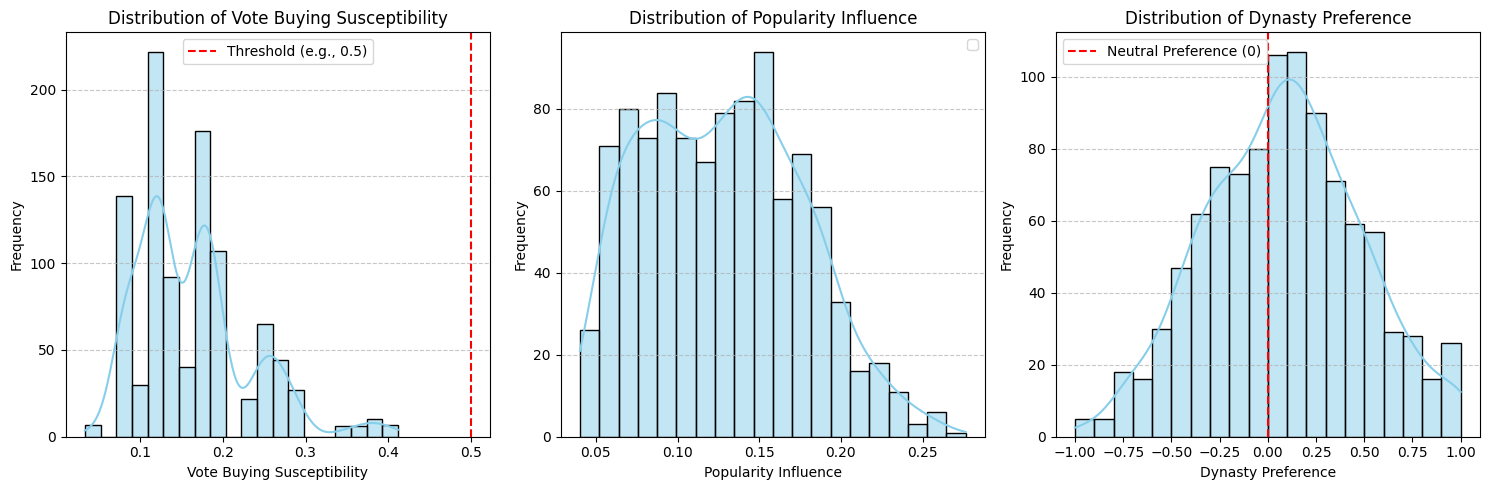

In [78]:
def plot_demographic_distributions(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    demo_data = [{'region': v.region, 'gender': v.gender, 'age_group': v.age_group, 'educ_attainment': v.educ_attainment, 'income_group': v.income_group, 'split': v.split} for v in voters]
    voter_df = pd.DataFrame(demo_data); demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']
    num_plots = len(demographic_columns); ncols = 2; nrows = (num_plots + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows)); axes = axes.flatten()
    fig.suptitle('Distribution of Voter Demographics in Simulation', fontsize=16, y=1.02)
    for i, col in enumerate(demographic_columns):
        ax = axes[i]; order = voter_df[col].value_counts().index
        sns.countplot(data=voter_df, y=col, ax=ax, order=order, palette='viridis'); ax.set_title(f'Distribution by {col.replace("_", " ").title()}'); ax.set_xlabel('Number of Voters'); ax.set_ylabel(col.replace("_", " ").title())
        for container in ax.containers: ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()

def plot_issue_stance_distributions(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    stance_data = [voter.issue_stances for voter in voters if hasattr(voter, 'issue_stances')]
    if not stance_data: print("No issue stance data collected."); return
    stance_df = pd.DataFrame(stance_data); issues = stance_df.columns; num_issues = len(issues)
    ncols = 2; nrows = (num_issues + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows)); axes = axes.flatten()
    fig.suptitle('Distribution of Voter Issue Stances', fontsize=16, y=1.01)
    for i, issue in enumerate(issues):
        ax = axes[i]; sns.histplot(data=stance_df, x=issue, ax=ax, kde=True, bins=20); ax.set_title(f'Stance on {issue.replace("_", " ").title()}'); ax.set_xlabel('Stance (User Defined 0-1 Scale)'); ax.set_ylabel('Number of Voters'); ax.set_xlim(0, 1)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.99]); plt.show()

def plot_candidate_issue_stances(model):
    # (Keep function as before)
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)];
    if not candidates: print("No candidate agents found."); return
    stance_data = []
    for cand in candidates:
        if hasattr(cand, 'issue_stances'):
            stance_entry = cand.issue_stances.copy(); stance_entry['CandidateID'] = cand.unique_id; stance_entry['Type'] = getattr(cand, 'politician_type', 'Unknown')
            stance_data.append(stance_entry)
    if not stance_data: print("No issue stance data collected."); return
    stance_df = pd.DataFrame(stance_data); stance_df['Label'] = stance_df.apply(lambda row: f"{row['CandidateID']} ({row['Type']})", axis=1); stance_df = stance_df.set_index('Label')
    issue_columns = [col for col in stance_df.columns if col not in ['CandidateID', 'Type']]
    heatmap_data = stance_df[issue_columns].astype(float)
    plt.figure(figsize=(10, 8)); sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, vmin=0, vmax=1); plt.title('Candidate Issue Stances (User Defined 0-1 Scale)'); plt.xlabel('Issue Area'); plt.ylabel('Candidate (Type)'); plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

def plot_stances_by_demographic(model, demographic_column, plot_type='box'):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    data_list = []
    for voter in voters:
        if hasattr(voter, 'issue_stances') and hasattr(voter, demographic_column):
            demo_value = getattr(voter, demographic_column)
            for issue, stance in voter.issue_stances.items(): data_list.append({'VoterID': voter.unique_id, demographic_column: demo_value, 'Issue': issue, 'Stance': stance})
    if not data_list: print(f"No stance or demographic data for '{demographic_column}'."); return
    stance_df = pd.DataFrame(data_list); categories = sorted(stance_df[demographic_column].unique())
    if demographic_column == 'age_group': age_order = ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']; categories = [cat for cat in age_order if cat in categories]
    elif demographic_column == 'income_group': income_order = ['poverty', 'low', 'middle', 'high']; categories = [cat for cat in income_order if cat in categories]
    elif demographic_column == 'educ_attainment': edu_order = ['no_edu', 'early_child', 'elem', 'hs', 'post_sec', 'short_tert', 'college', 'post_bac']; categories = [cat for cat in edu_order if cat in categories]
    print(f"\nVisualizing Issue Stances by {demographic_column.replace('_', ' ').title()}...")
    plot_kind = plot_type if plot_type in ['box', 'violin'] else 'box'
    g = sns.catplot(data=stance_df, x=demographic_column, y='Stance', col='Issue', kind=plot_kind, col_wrap=3, sharey=True, height=4, aspect=1.2, order=categories, palette='viridis', legend=False)
    g.fig.suptitle(f'Voter Issue Stances by {demographic_column.replace("_", " ").title()}', y=1.03, fontsize=16)
    g.set_axis_labels(demographic_column.replace("_", " ").title(), "Stance (User Defined 0-1 Scale)"); g.set_titles("Issue: {col_name}"); g.set(ylim=(0, 1))
    for ax in g.axes.flatten(): ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def analyze_decisive_factors(election, analysis_results):
    # (Keep function as before)
    candidates = election.get_candidates()
    if 'evaluations' not in analysis_results or analysis_results['evaluations'].empty: print("Evaluation data not available/empty."); return None
    eval_df = analysis_results['evaluations']; popularity = {c.name: getattr(c, 'popularity', 0.5) for c in candidates if hasattr(c, 'name')} # Use getattr
    mean_evals = eval_df.groupby('candidate_name')['evaluation_score'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    for _, row in mean_evals.iterrows():
        cand_name = row['candidate_name']
        if cand_name in popularity:
            plt.scatter(popularity[cand_name], row['evaluation_score'], s=100, label=cand_name); plt.annotate(cand_name, (popularity[cand_name], row['evaluation_score']), textcoords="offset points", xytext=(0,10), ha='center')
    plt.xlabel('Candidate Popularity'); plt.ylabel('Mean Evaluation Score'); plt.title('Relationship Between Candidate Popularity and Voter Evaluation'); plt.grid(True, alpha=0.3); plt.savefig('popularity_vs_evaluation.png'); plt.show()
    return mean_evals

def plot_voter_evaluation_scores(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]; candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates: print("No voters or candidates found."); return
    plot_data = []; first_choice_scores = defaultdict(list)
    for voter in voters:
        if not voter.ranked_vote: continue
        first_choice_candidate = voter.ranked_vote[0]
        for cand_id, score in voter.approval_scores.items():
            plot_data.append({'CandidateID': cand_id, 'EvaluationScore': score})
            if cand_id == first_choice_candidate.unique_id: first_choice_scores[cand_id].append(score)
    if not plot_data: print("No evaluation scores found."); return
    eval_df = pd.DataFrame(plot_data); avg_first_choice_scores = {cand_id: np.mean(scores) if scores else 0 for cand_id, scores in first_choice_scores.items()}
    avg_plot_data = []; candidate_order = sorted([c.unique_id for c in candidates])
    for cand_id in candidate_order:
         if cand_id in avg_first_choice_scores: avg_plot_data.append({'CandidateID': cand_id, 'AverageScore': avg_first_choice_scores[cand_id]})
    avg_df = pd.DataFrame(avg_plot_data)
    plt.figure(figsize=(14, 7)); sns.boxplot(data=eval_df, x='CandidateID', y='EvaluationScore', order=candidate_order, palette='viridis', showfliers=False)
    if not avg_df.empty: sns.stripplot(data=avg_df, x='CandidateID', y='AverageScore', order=candidate_order, marker='D', s=10, color='red', label='Avg Score from 1st Pref Voters', jitter=False)
    plt.title('Distribution of Voter Evaluation Scores per Candidate'); plt.xlabel('Candidate ID'); plt.ylabel('Issue-Based Evaluation Score (0-1)'); plt.ylim(-0.05, 1.05); plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', linestyle='--', alpha=0.7); plt.legend(loc='best'); plt.tight_layout(); plt.show()

# --- NEW Visualization Function: Popularity Impact ---
def plot_popularity_impact_on_evaluation(model):
    """
    Visualizes how much candidate popularity influenced the final evaluation score
    relative to the voter's susceptibility to popularity.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voters or candidates found.")
        return

    impact_data = []
    for voter in voters:
        if not hasattr(voter, 'popularity_influence'): continue # Skip if attribute missing

        for candidate in candidates:
            final_score = voter.evaluate_candidate(candidate)
            issue_score = voter.get_issue_score(candidate) # Use helper method
            popularity_impact = final_score - issue_score

            impact_data.append({
                'VoterID': voter.unique_id,
                'CandidateID': candidate.unique_id,
                'PopularityInfluence': voter.popularity_influence,
                'PopularityImpact': popularity_impact,
                'CandidatePopularity': getattr(candidate, 'popularity', 0.5) # For coloring
            })

    if not impact_data:
        print("Could not calculate popularity impact data.")
        return

    impact_df = pd.DataFrame(impact_data)

    # Create scatter plot with regression line
    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=impact_df,
        x='PopularityInfluence',
        y='PopularityImpact',
        scatter_kws={'alpha': 0.2, 's': 10}, # Make points smaller and transparent
        line_kws={'color': 'red'}
    )

    plt.title('Impact of Popularity on Voter Evaluation Score')
    plt.xlabel('Voter Popularity Influence (Susceptibility)')
    plt.ylabel('Popularity Impact (Final Score - Issue Score)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', lw=1, linestyle=':') # Line at zero impact
    plt.tight_layout()
    plt.show()

    # Optional: Show impact colored by candidate popularity
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=impact_df,
        x='PopularityInfluence',
        y='PopularityImpact',
        hue='CandidatePopularity',
        palette='coolwarm',
        alpha=0.3,
        s=15
    )
    plt.title('Impact of Popularity on Voter Evaluation (Colored by Candidate Popularity)')
    plt.xlabel('Voter Popularity Influence (Susceptibility)')
    plt.ylabel('Popularity Impact (Final Score - Issue Score)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', lw=1, linestyle=':')
    plt.legend(title='Cand. Pop.')
    plt.tight_layout()
    plt.show()

def plot_dynasty_pref_vs_evaluation_binned(model, n_bins=10):
    """
    Visualizes the relationship between voter dynasty preference (binned)
    and the average final evaluation score given to dynastic vs non-dynastic candidates.

    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
        n_bins (int): The number of bins to group voter dynasty preference into.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voters or candidates found.")
        return

    eval_data = []
    # Check if scores have been calculated
    if not any(hasattr(v, 'approval_scores') and v.approval_scores for v in voters):
         print("Warning: Voter approval scores not calculated yet. Run model.step() first.")
         # Attempt to run step if scores are missing
         try:
             print("Attempting to run model.step() to calculate scores...")
             model.step()
             # Re-check after running step
             if not any(hasattr(v, 'approval_scores') and v.approval_scores for v in voters):
                 print("Scores still missing after running step. Cannot generate plot.")
                 return
         except Exception as e:
             print(f"Error running model.step(): {e}. Cannot generate plot.")
             return


    for voter in voters:
        # Ensure voter has the necessary attributes
        if not hasattr(voter, 'dynasty_preference') or not hasattr(voter, 'approval_scores') or not voter.approval_scores:
             # print(f"Skipping voter {voter.unique_id} due to missing attributes or scores.") # Optional debug print
             continue

        for cand in candidates:
            cand_id = cand.unique_id
            # Check if score exists for this candidate (it should if step ran)
            if cand_id not in voter.approval_scores:
                # print(f"Score for candidate {cand_id} not found for voter {voter.unique_id}") # Optional debug print
                continue

            score = voter.approval_scores[cand_id]
            is_dynasty = getattr(cand, 'is_dynasty', False) # Default to False if attribute missing

            eval_data.append({
                'VoterID': voter.unique_id,
                'CandidateID': cand_id,
                'DynastyPreference': voter.dynasty_preference, # Voter's preference (-1 to 1)
                'FinalEvaluationScore': score, # The final combined score
                'IsDynasty': is_dynasty
            })

    if not eval_data:
        print("Could not gather evaluation data for dynasty plot.")
        return

    eval_df = pd.DataFrame(eval_data)

    # --- Binning and Aggregation ---
    # Create bins for dynasty preference
    bins = np.linspace(-1, 1, n_bins + 1)
    labels = [(bins[i] + bins[i+1]) / 2 for i in range(n_bins)] # Use bin centers as labels

    eval_df['PreferenceBin'] = pd.cut(eval_df['DynastyPreference'], bins=bins, labels=labels, include_lowest=True)

    # Calculate mean and standard error per bin and dynasty status
    agg_data = eval_df.groupby(['PreferenceBin', 'IsDynasty'], observed=False)['FinalEvaluationScore'].agg(['mean', 'sem']).reset_index() # sem = standard error of the mean

    # --- Plotting ---
    print("\nPlotting Binned Voter Dynasty Preference vs Average Evaluation Score...")
    plt.figure(figsize=(10, 6))

    # Plot Dynastic Candidates
    dynasty_true = agg_data[agg_data['IsDynasty'] == True]
    plt.errorbar(dynasty_true['PreferenceBin'], dynasty_true['mean'], yerr=dynasty_true['sem'],
                 fmt='-o', capsize=5, label='Dynastic Candidate', color='orange', alpha=0.8)

    # Plot Non-Dynastic Candidates
    dynasty_false = agg_data[agg_data['IsDynasty'] == False]
    plt.errorbar(dynasty_false['PreferenceBin'], dynasty_false['mean'], yerr=dynasty_false['sem'],
                 fmt='-s', capsize=5, label='Non-Dynastic Candidate', color='grey', alpha=0.8)


    plt.title('Voter Dynasty Preference vs. Average Candidate Evaluation Score (Binned)')
    plt.xlabel('Voter Dynasty Preference Bin Center (-1=Anti, +1=Pro)')
    plt.ylabel('Average Final Evaluation Score (0-1)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(-0.05, 1.05)
    plt.xlim(-1.05, 1.05)
    plt.legend(title='Candidate Type', loc='best')
    plt.tight_layout()
    plt.show()

def plot_turnout_by_demographic(model):
    """
    Calculates and plots the voter turnout percentage for various demographic groups
    based on the simulation results.

    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
               Requires VoterAgents to have demographic attributes and the 'will_vote' attribute.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    if not voters:
        print("No voter agents found in the model.")
        return

    # Check if the turnout simulation has likely run (i.e., will_vote exists)
    # Check the first voter, assuming all voters will have the attribute if one does after step()
    if not hasattr(voters[0], 'will_vote'):
        print("Warning: Voter agents do not have the 'will_vote' attribute.")
        print("Please ensure model.step() has been run before calling this function.")
        return # Return if attribute is missing


    # --- Collect Data ---
    demographic_data = []
    demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']

    for voter in voters:
        # Initialize data_entry for each voter
        data_entry = {'will_vote': getattr(voter, 'will_vote', False)} # Default to False if missing
        valid_entry = True
        for col in demographic_columns:
            if hasattr(voter, col):
                data_entry[col] = getattr(voter, col)
            else:
                # Print warning only once per missing attribute type for brevity
                if not hasattr(plot_turnout_by_demographic, f"warned_{col}"):
                     print(f"Warning: At least one voter missing demographic attribute '{col}'. Voters without it will be skipped for this plot.")
                     setattr(plot_turnout_by_demographic, f"warned_{col}", True)
                valid_entry = False
                break # Skip this voter if any demographic is missing
        if valid_entry:
            # Ensure all expected keys are present before appending
            if all(key in data_entry for key in demographic_columns + ['will_vote']):
                 demographic_data.append(data_entry)

    # Reset warnings for next call
    for col in demographic_columns:
         if hasattr(plot_turnout_by_demographic, f"warned_{col}"):
             delattr(plot_turnout_by_demographic, f"warned_{col}")


    if not demographic_data:
        print("No valid voter data with demographics and turnout status found.")
        return

    voter_df = pd.DataFrame(demographic_data)
    # Convert will_vote to integer (1 for True, 0 for False) for mean calculation
    voter_df['will_vote'] = voter_df['will_vote'].astype(int)


    # --- Plotting ---
    print("\nPlotting Simulated Voter Turnout Rate by Demographic Group...")

    num_plots = len(demographic_columns)
    ncols = 2
    nrows = (num_plots + ncols - 1) // ncols # Calculate necessary rows

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() # Flatten the axes array for easy iteration

    fig.suptitle('Simulated Voter Turnout Rate by Demographic Group', fontsize=18, y=1.03)

    for i, col in enumerate(demographic_columns):
        ax = axes[i]

        # Calculate turnout percentage for each category in the demographic column
        # Check if column exists and has data before grouping
        if col not in voter_df.columns or voter_df[col].isnull().all():
             print(f"Skipping plot for '{col}' due to missing data.")
             ax.set_title(f'Turnout by {col.replace("_", " ").title()} (No Data)')
             ax.text(0.5, 0.5, 'No Data Available', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
             continue # Skip to the next plot if no data for this column

        # Ensure the grouping column is treated as categorical for correct grouping
        voter_df[col] = voter_df[col].astype('category')

        turnout_rates = voter_df.groupby(col, observed=False)['will_vote'].mean() * 100 # Use observed=False
        turnout_rates = turnout_rates.sort_values(ascending=False) # Sort for better visualization

        # Define order for specific categorical plots if needed
        order = turnout_rates.index
        # Define known order for specific demographics
        if col == 'age_group':
            age_order = ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']
            order = pd.Categorical(voter_df[col].unique(), categories=age_order, ordered=True)
            order = order.dropna().sort_values() # Use only categories present in the data, sorted correctly
            # Recalculate turnout rates with the correct order if needed (or pass order to sns.barplot)
            turnout_rates = turnout_rates.reindex(order).dropna()

        elif col == 'income_group':
            income_order = ['below_poverty_line', 'low_income', 'middle_income', 'high_income']
            order = pd.Categorical(voter_df[col].unique(), categories=income_order, ordered=True)
            order = order.dropna().sort_values()
            turnout_rates = turnout_rates.reindex(order).dropna()

        elif col == 'educ_attainment':
            edu_order = ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']
            order = pd.Categorical(voter_df[col].unique(), categories=edu_order, ordered=True)
            order = order.dropna().sort_values()
            turnout_rates = turnout_rates.reindex(order).dropna()
        else:
             # For others like region, gender, split, sorted by rate is fine
             order = turnout_rates.index


        # Check if there are any rates to plot after potential filtering/reindexing
        if turnout_rates.empty:
             print(f"Skipping plot for '{col}' as no turnout rates could be calculated.")
             ax.set_title(f'Turnout by {col.replace("_", " ").title()} (No Rates)')
             ax.text(0.5, 0.5, 'No Rates Calculated', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
             continue


        # Create the bar plot
        sns.barplot(x=turnout_rates.index, y=turnout_rates.values, ax=ax, order=order, palette='viridis')

        # Add percentage labels to the bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=9)

        # Set titles and labels
        ax.set_title(f'Turnout by {col.replace("_", " ").title()}')
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel('Turnout Rate (%)')
        ax.set_ylim(0, 100) # Y-axis from 0% to 100%

        # --- CORRECTED LINE ---
        # Set rotation and alignment for x-tick labels using plt.setp
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to prevent title overlap
    plt.show()

def plot_vote_buying_effect(model):
    """
    Visualizes the change in evaluation scores due to vote buying,
    faceted by candidate vote buying propensity.

    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
               Requires VoterAgents to have 'initial_approval_scores' and 'approval_scores'.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voters or candidates found.")
        return

    # Check if necessary score attributes exist on the first voter (as a proxy)
    if not hasattr(voters[0], 'initial_approval_scores') or not hasattr(voters[0], 'approval_scores'):
        print("Warning: Score attributes ('initial_approval_scores' or 'approval_scores') not found.")
        print("Ensure VoterAgent.step stores both initial and final scores. Run model.step() first.")
        return

    plot_data = []
    for voter in voters:
        # Ensure scores were calculated for this specific voter
        initial_scores_dict = getattr(voter, 'initial_approval_scores', None)
        final_scores_dict = getattr(voter, 'approval_scores', None)
        if not initial_scores_dict or not final_scores_dict:
            continue # Skip voter if scores are missing

        for cand in candidates:
            cand_id = cand.unique_id
            initial_score = initial_scores_dict.get(cand_id, None)
            final_score = final_scores_dict.get(cand_id, None)
            propensity = getattr(cand, 'vote_buying_propensity', 0.0) # Get candidate propensity

            if initial_score is not None and final_score is not None:
                score_change = final_score - initial_score
                # Include only data points where a score increase occurred
                if score_change > 1e-6: # Use tolerance for floating point comparison
                     plot_data.append({
                         'VoterSusceptibility': getattr(voter, 'vote_buying_susceptibility', 0.0),
                         'CandidatePropensity': propensity,
                         'ScoreChange': score_change
                     })

    if not plot_data:
        print("No score changes due to vote buying were recorded or data is missing.")
        print("(This might be expected if no vote buying offers were accepted in the simulation step)")
        return

    effect_df = pd.DataFrame(plot_data)

    # --- Plotting Score Change Distribution ---
    print("\nPlotting Distribution of Score Changes Due to Vote Buying...")

    # Bin candidate propensity for faceting/hue
    propensity_bins = [-0.01, 0.3, 0.6, 1.0] # Bins: Low(0-0.3], Medium(0.3-0.6], High(0.6-1.0]
    propensity_labels = ['Low Propensity (0-0.3)', 'Medium Propensity (0.3-0.6)', 'High Propensity (0.6-1.0)']
    # Use right=True to include the right edge (e.g., 0.3 is in Low)
    effect_df['PropensityCategory'] = pd.cut(effect_df['CandidatePropensity'],
                                             bins=propensity_bins, labels=propensity_labels,
                                             right=True)

    # Check if any categories ended up empty after filtering score_change > 0
    if effect_df['PropensityCategory'].isnull().all():
        print("Warning: Could not categorize candidate propensities for plotting.")
        # Fallback: Plot without faceting if categorization fails
        plt.figure(figsize=(8, 5))
        sns.histplot(data=effect_df, x='ScoreChange', kde=False, bins=15)
        plt.title('Distribution of Score Increase Due to Vote Buying (All Candidates)')
        plt.xlabel("Score Increase (Final - Initial)")
        plt.ylabel("Number of Occurrences")
    else:
        # Histogram of score changes, faceted by candidate propensity category
        g = sns.displot(data=effect_df, x='ScoreChange', col='PropensityCategory',
                        kind='hist', kde=False, height=4, aspect=1.2, bins=15,
                        col_order=propensity_labels) # Ensure correct order

        g.fig.suptitle('Distribution of Evaluation Score Increase Due to Accepted Vote Buying Offers', y=1.03)
        g.set_axis_labels("Score Increase (Final - Initial)", "Number of Occurrences")
        g.set_titles("Candidate Propensity: {col_name}")

    # Set x-axis limits to focus around 0 and the boost value (e.g., 0.3)
    max_change = effect_df['ScoreChange'].max() if not effect_df.empty else 0.4
    plt.xlim(-0.05, max(0.4, max_change + 0.05)) # Ensure x-axis covers at least 0 to 0.4

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

def analyze_distributions(model):
    """
    Analyze and plot the distributions of key variables for VoterAgents.
    
    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
    """
    # Extract VoterAgents from the model
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    if not voters:
        print("No voter agents found in the model.")
        return

    # Collect data for the key variables
    data = {
        "vote_buying_susceptibility": [],
        "popularity_influence": [],
        "dynasty_preference": []
    }

    for voter in voters:
        # Ensure the voter has the required attributes
        if hasattr(voter, "vote_buying_susceptibility"):
            data["vote_buying_susceptibility"].append(voter.vote_buying_susceptibility)
        if hasattr(voter, "popularity_influence"):
            data["popularity_influence"].append(voter.popularity_influence)
        if hasattr(voter, "dynasty_preference"):
            data["dynasty_preference"].append(voter.dynasty_preference)

    # Plot the distributions
    print("\nPlotting distributions of key variables...")
    num_vars = len(data)
    fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 5), sharey=False)

    for i, (key, values) in enumerate(data.items()):
        ax = axes[i] if num_vars > 1 else axes
        sns.histplot(values, kde=True, bins=20, ax=ax, color="skyblue")
        ax.set_title(f"Distribution of {key.replace('_', ' ').title()}")
        ax.set_xlabel(key.replace("_", " ").title())
        ax.set_ylabel("Frequency")
        ax.grid(axis="y", linestyle="--", alpha=0.7)

        # Highlight anomalies (e.g., extreme values)
        if key == "vote_buying_susceptibility":
            ax.axvline(0.5, color="red", linestyle="--", label="Threshold (e.g., 0.5)")
        elif key == "dynasty_preference":
            ax.axvline(0, color="red", linestyle="--", label="Neutral Preference (0)")
        ax.legend()

    plt.tight_layout()
    plt.show()

# Simple Preferences
model = ElectionModel(num_voters=1000, num_candidates=5)

model.step()
analyze_distributions(model)


# Evaluations

## Helper Functions

In [79]:
def calculate_voter_satisfaction(model, winner):
    """
    Calculate the average voter satisfaction for a given winner in the model.
    
    Args:
        model: The ElectionModel instance for the current simulation run.
        winner: The CandidateAgent who won the election.
    
    Returns:
        float: The average satisfaction score of voters who turned out.
    """
    if not winner:
        return None  # No winner, no satisfaction to calculate
    
    voters = [v for v in model.schedule.agents if isinstance(v, VoterAgent) and v.will_vote]
    if not voters:
        return None  # No voters turned out
    
    # Calculate satisfaction for each voter
    satisfaction_scores = [voter.get_issue_score(winner) for voter in voters]
    
    # Return the average satisfaction score
    return np.mean(satisfaction_scores) if satisfaction_scores else None

In [80]:
def calculate_issue_representation_distance(model, winner):
    """
    Calculate the distance between the winner's issue stances and the average voter stance.

    Args:
        model: The ElectionModel instance for the current simulation run.
        winner: The CandidateAgent who won the election.

    Returns:
        float: The weighted Euclidean distance between the winner's stance and the average voter stance.
    """
    if not winner:
        return None  # No winner, no distance to calculate

    voters = [v for v in model.schedule.agents if isinstance(v, VoterAgent)]
    if not voters:
        return None  # No voters in the model

    # Calculate average voter stance and priority
    total_stances = defaultdict(float)
    total_priorities = defaultdict(float)
    total_voters = 0

    for voter in voters:
        if not hasattr(voter, 'issue_stances') or not hasattr(voter, 'issue_priorities'):
            continue  # Skip voters without stances or priorities

        for issue, stance in voter.issue_stances.items():
            total_stances[issue] += stance
        for issue, priority in voter.issue_priorities.items():
            total_priorities[issue] += priority

        total_voters += 1

    if total_voters == 0:
        return None  # No valid voters

    # Compute average stances and priorities
    avg_stances = {issue: total / total_voters for issue, total in total_stances.items()}
    avg_priorities = {issue: total / total_voters for issue, total in total_priorities.items()}

    # Calculate weighted Euclidean distance between winner's stances and average voter stances
    distance = 0.0
    for issue, avg_stance in avg_stances.items():
        winner_stance = winner.issue_stances.get(issue, 0.5)  # Default to neutral stance if missing
        weight = avg_priorities.get(issue, 1.0)  # Default to equal weight if missing
        distance += weight * (winner_stance - avg_stance) ** 2

    return distance ** 0.5  # Return the square root of the sum of squared differences

## Evaluation Functions

In [ ]:
if __name__ == "__main__" or True:  # For Jupyter notebook compatibility
    NUM_RUNS = 25  # Or 100, or more depending on time
    NUM_VOTERS = 1000
    NUM_CANDIDATES = 5
    results = []
    
    print(f"Running {NUM_RUNS} simulation runs...")
    for i in range(NUM_RUNS):
        print(f"\n--- Run {i+1}/{NUM_RUNS} ---")
        election_model = ElectionModel(num_voters=NUM_VOTERS, num_candidates=NUM_CANDIDATES, verbose=False)
        election_model.step()  # Run the simulation step

        # Calculate voter satisfaction for each voting system
        plurality_satisfaction = calculate_voter_satisfaction(election_model, election_model.plurality_winner)
        irv_satisfaction = calculate_voter_satisfaction(election_model, election_model.irv_winner)
        approval_satisfaction = calculate_voter_satisfaction(election_model, election_model.approval_winner)
        borda_satisfaction = calculate_voter_satisfaction(election_model, election_model.borda_winner)
        condorcet_satisfaction = calculate_voter_satisfaction(election_model, election_model.condorcet_winner)

        # Calculate issue representation distance for each voting system
        plurality_distance = calculate_issue_representation_distance(election_model, election_model.plurality_winner)
        irv_distance = calculate_issue_representation_distance(election_model, election_model.irv_winner)
        approval_distance = calculate_issue_representation_distance(election_model, election_model.approval_winner)
        borda_distance = calculate_issue_representation_distance(election_model, election_model.borda_winner)
        condorcet_distance = calculate_issue_representation_distance(election_model, election_model.condorcet_winner)
        
        # Store the winners from this run
        run_result = {
            'run': i + 1,
            'turnout_pct': (election_model.voters_turnout_count / election_model.num_voters) * 100,
            'plurality_winner': getattr(election_model.plurality_winner, 'unique_id', None),
            'irv_winner': getattr(election_model.irv_winner, 'unique_id', None),
            'approval_winner': getattr(election_model.approval_winner, 'unique_id', None),
            'borda_winner': getattr(election_model.borda_winner, 'unique_id', None),
            'condorcet_winner': getattr(election_model.condorcet_winner, 'unique_id', None),
            'borda_scores': election_model.borda_scores,
            'plurality_satisfaction': plurality_satisfaction,
            'irv_satisfaction': irv_satisfaction,
            'approval_satisfaction': approval_satisfaction,
            'borda_satisfaction': borda_satisfaction,
            'condorcet_satisfaction': condorcet_satisfaction,
            'plurality_distance': plurality_distance,
            'irv_distance': irv_distance,
            'approval_distance': approval_distance,
            'borda_distance': borda_distance,
            'condorcet_distance': condorcet_distance,
        }
        results.append(run_result)
    
    print(f"\n--- Simulation Complete ({NUM_RUNS} runs) ---")
    results_df = pd.DataFrame(results)



Running 25 simulation runs...

--- Run 1/25 ---

--- Run 2/25 ---

--- Run 3/25 ---

--- Run 4/25 ---

--- Run 5/25 ---

--- Run 6/25 ---

--- Run 7/25 ---

--- Run 8/25 ---

--- Run 9/25 ---

--- Run 10/25 ---

--- Run 11/25 ---

--- Run 12/25 ---

--- Run 13/25 ---

--- Run 14/25 ---

--- Run 15/25 ---

--- Run 16/25 ---

--- Run 17/25 ---

--- Run 18/25 ---

--- Run 19/25 ---

--- Run 20/25 ---

--- Run 21/25 ---

--- Run 22/25 ---

--- Run 23/25 ---

--- Run 24/25 ---

--- Run 25/25 ---

--- Simulation Complete (25 runs) ---

=== Simulation Results ===
Total Runs: 25
Average Turnout Rate: 83.48%

=== Winner Frequency Analysis ===

PLURALITY WINNERS BY CHARACTERISTICS:
  Dynasties: 11/25 (44.0%)
  Non-Dynasties: 14/25 (56.0%)
  Unpopular (-): 3/25 (12.0%)
  Mildly Popular (<0.5): 4/25 (16.0%)
  Popular (0.5-1): 18/25 (72.0%)
  Engaged in Vote Buying: 25/25 (100.0%)
  Did Not Vote Buy: 0/25 (0.0%)
  Populist: 3/25 (12.0%)
  Liberal: 4/25 (16.0%)
  Conservative: 4/25 (16.0%)
  Progres

In [ ]:
print("\n=== Simulation Results ===")
print(f"Total Runs: {len(results_df)}")
print(f"Average Turnout Rate: {results_df['turnout_pct'].mean():.2f}%")
    
 # Updated Results Analysis
print("\n=== Winner Frequency Analysis ===")

# Helper function to categorize popularity
def categorize_popularity(popularity_score):
    if popularity_score < 0:
        return "Unpopular (-)"
    elif 0 <= popularity_score < 0.5:
        return "Mildly Popular (<0.5)"
    elif 0.5 <= popularity_score <= 1:
        return "Popular (0.5-1)"
    else:
        return "Unknown"

# Analyze winners by characteristics
methods = ['plurality', 'irv', 'approval', 'borda', 'condorcet']
for method in methods:
    col = f'{method}_winner'
    if results_df[col].notna().any():
        print(f"\n{method.upper()} WINNERS BY CHARACTERISTICS:")
        
        # Collect characteristics of winners
        characteristics = {
            "Dynasties": 0,
            "Non-Dynasties": 0,
            "Unpopular (-)": 0,
            "Mildly Popular (<0.5)": 0,
            "Popular (0.5-1)": 0,
            "Engaged in Vote Buying": 0,
            "Did Not Vote Buy": 0,
            "Populist": 0,
            "Liberal": 0,
            "Conservative": 0,
            "Progressive": 0,
            "Did Not Vote Buy": 0,
        }
        
        # Iterate through winners and categorize
        for winner_id in results_df[col].dropna():
            winner = next((c for c in election_model.schedule.agents if isinstance(c, CandidateAgent) and c.unique_id == winner_id), None)
            if winner:
                # Dynasty status
                if winner.is_dynasty:
                    characteristics["Dynasties"] += 1
                else:
                    characteristics["Non-Dynasties"] += 1
                
                # Popularity
                popularity_category = categorize_popularity(winner.popularity)
                characteristics[popularity_category] += 1
                
                # Archetype
                archetype = winner.politician_type
                if archetype in characteristics:
                    characteristics[archetype] += 1
                
                # Vote buying engagement
                if winner.engaged_in_vote_buying:
                    characteristics["Engaged in Vote Buying"] += 1
                else:
                    characteristics["Did Not Vote Buy"] += 1
        
        # Display results
        total_winners = len(results_df[col].dropna())
        for char, count in characteristics.items():
            percentage = (count / total_winners) * 100
            print(f"  {char}: {count}/{total_winners} ({percentage:.1f}%)")

In [82]:
def calculate_winner_agreement(results_df):
    """
    Calculate how often different pairs of voting systems produce the same winner.

    Args:
        results_df (pd.DataFrame): DataFrame containing the results of the simulation runs.

    Returns:
        pd.DataFrame: A DataFrame showing the agreement percentages for each pair of voting systems.
    """
    methods = ['plurality_winner', 'irv_winner', 'approval_winner', 'borda_winner', 'condorcet_winner']
    agreement_counts = {}

    # Iterate through all pairs of methods
    for i, method1 in enumerate(methods):
        for method2 in methods[i + 1:]:
            # Count how often the winners match
            matches = (results_df[method1] == results_df[method2]).sum()
            total_runs = len(results_df)
            agreement_percentage = (matches / total_runs) * 100
            agreement_counts[(method1, method2)] = agreement_percentage

    # Convert to a DataFrame for better visualization
    agreement_df = pd.DataFrame([
        {'Method 1': m1, 'Method 2': m2, 'Agreement (%)': agreement_counts[(m1, m2)]}
        for m1, m2 in agreement_counts
    ])

    return agreement_df

# Perform the analysis
agreement_df = calculate_winner_agreement(results_df)

# Display the results
print("\n=== Winner Agreement Analysis ===")
print(agreement_df)


=== Winner Agreement Analysis ===
           Method 1          Method 2  Agreement (%)
0  plurality_winner        irv_winner           96.0
1  plurality_winner   approval_winner           80.0
2  plurality_winner      borda_winner           88.0
3  plurality_winner  condorcet_winner           92.0
4        irv_winner   approval_winner           84.0
5        irv_winner      borda_winner           92.0
6        irv_winner  condorcet_winner           96.0
7   approval_winner      borda_winner           76.0
8   approval_winner  condorcet_winner           80.0
9      borda_winner  condorcet_winner           96.0


In [83]:
def analyze_utilitarian_efficiency(results_df):
    """Analyze the average Borda score of the winners for each voting system."""
    methods = ['plurality_winner', 'irv_winner', 'approval_winner', 'borda_winner', 'condorcet_winner']
    efficiency_results = {}

    for method in methods:
        total_borda_score = 0
        count = 0

        for _, row in results_df.iterrows():
            winner_id = row[method]
            if winner_id and row['borda_scores']:
                total_borda_score += row['borda_scores'].get(winner_id, 0)
                count += 1

        if count > 0:
            efficiency_results[method] = total_borda_score / count
        else:
            efficiency_results[method] = None

    return efficiency_results


# Perform the analysis
efficiency_results = analyze_utilitarian_efficiency(results_df)

# Display the results
print("\n=== Utilitarian Efficiency Analysis ===")
for method, avg_borda_score in efficiency_results.items():
    print(f"{method.replace('_winner', '').title()} Winner: Average Borda Score = {avg_borda_score:.2f}" if avg_borda_score is not None else f"{method.replace('_winner', '').title()} Winner: No Data")


=== Utilitarian Efficiency Analysis ===
Plurality Winner: Average Borda Score = 2650.56
Irv Winner: Average Borda Score = 2658.08
Approval Winner: Average Borda Score = 2579.48
Borda Winner: Average Borda Score = 2666.96
Condorcet Winner: Average Borda Score = 2663.84


In [84]:
# Calculate overall average satisfaction for each voting system
print("\n=== Issue Representation (Average Voter Satisfaction) ===")
satisfaction_columns = [
    'plurality_satisfaction',
    'irv_satisfaction',
    'approval_satisfaction',
    'borda_satisfaction',
    'condorcet_satisfaction',
]

for col in satisfaction_columns:
    avg_satisfaction = results_df[col].mean()
    print(f"{col.replace('_satisfaction', '').title()} Winner: Average Satisfaction = {avg_satisfaction:.4f}")


=== Issue Representation (Average Voter Satisfaction) ===
Plurality Winner: Average Satisfaction = 0.7519
Irv Winner: Average Satisfaction = 0.7536
Approval Winner: Average Satisfaction = 0.7562
Borda Winner: Average Satisfaction = 0.7518
Condorcet Winner: Average Satisfaction = 0.7537


In [85]:
print("\n=== Issue Representation Distance Analysis ===")
distance_columns = [
    'plurality_distance',
    'irv_distance',
    'approval_distance',
    'borda_distance',
    'condorcet_distance',
]

for col in distance_columns:
    avg_distance = results_df[col].mean()
    print(f"{col.replace('_distance', '').title()} Winner: Average Distance = {avg_distance:.4f}")


=== Issue Representation Distance Analysis ===
Plurality Winner: Average Distance = 0.2032
Irv Winner: Average Distance = 0.2007
Approval Winner: Average Distance = 0.1963
Borda Winner: Average Distance = 0.2037
Condorcet Winner: Average Distance = 0.2001
